<a href="https://colab.research.google.com/github/imalamin455/Hello-Mars/blob/main/Global_Commodity_Prices_2000_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Global_Commodity_Prices_2000_2026.csv to Global_Commodity_Prices_2000_2026 (10).csv


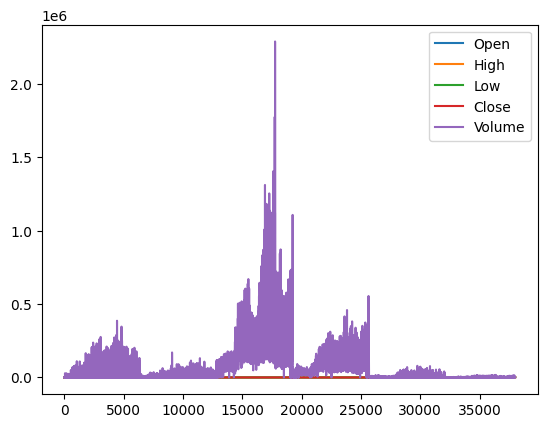

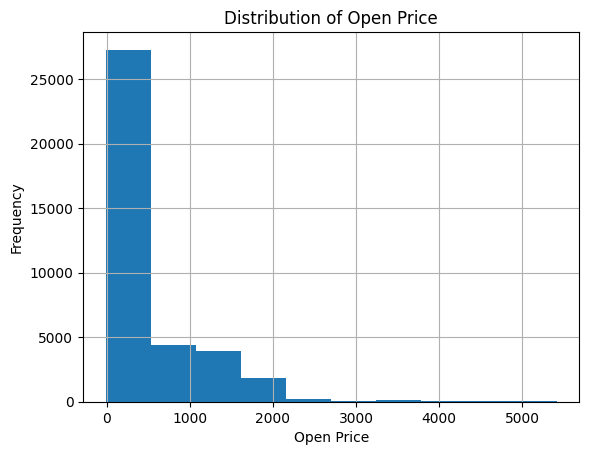

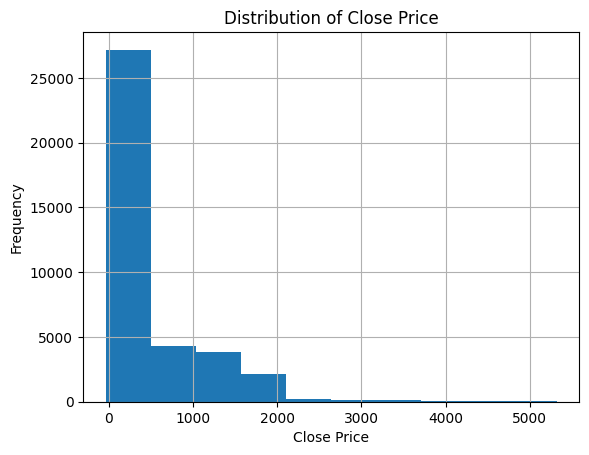

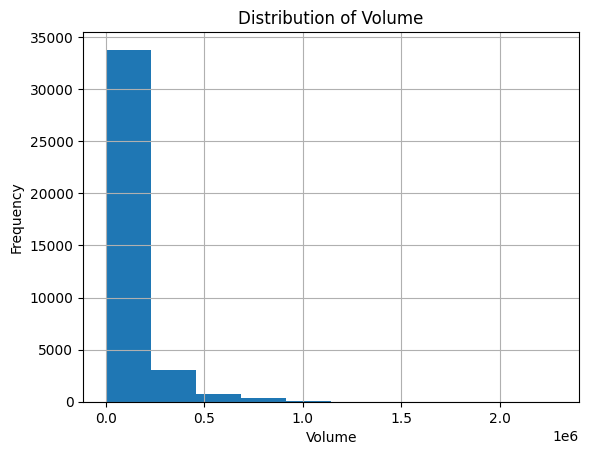

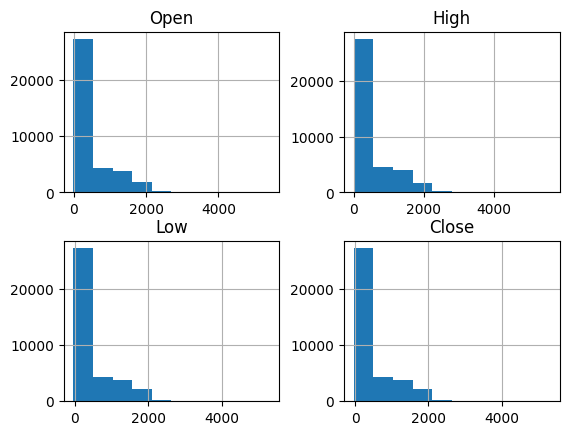

Skewness: Open      2.124646
High      2.135176
Low       2.109723
Close     2.121637
Volume    3.047460
dtype: float64
         Date        Open        High         Low       Close  Volume Ticker  \
0  2000-08-30  273.899994  273.899994  273.899994  273.899994       0   GC=F   
1  2000-08-31  274.799988  278.299988  274.799988  278.299988       0   GC=F   
2  2000-09-01  277.000000  277.000000  277.000000  277.000000       0   GC=F   
3  2000-09-05  275.799988  275.799988  275.799988  275.799988       2   GC=F   
4  2000-09-06  274.200012  274.200012  274.200012  274.200012       0   GC=F   

  Commodity  
0      Gold  
1      Gold  
2      Gold  
3      Gold  
4      Gold  
(38002, 8)
         Date        Open        High         Low       Close  Volume Ticker  \
0  2000-08-30  273.899994  273.899994  273.899994  273.899994       0   GC=F   
1  2000-08-31  274.799988  278.299988  274.799988  278.299988       0   GC=F   
2  2000-09-01  277.000000  277.000000  277.000000  277.000000   

In [15]:
from numpy._core import numeric
###1. IMPORT & DATA LOADING

from google.colab import files
uploaded = files.upload()

###Import Libraries
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset

df = pd.read_csv("Global_Commodity_Prices_2000_2026.csv")
df.plot()

##############################################################Histogram (Distribution)#############################################
#Histogram for Open price
plt.figure()
df['Open'].hist()

plt.title("Distribution of Open Price")
plt.xlabel("Open Price")
plt.ylabel("Frequency")

plt.show()
# Histogram for Close price
plt.figure()
df['Close'].hist()

plt.title("Distribution of Close Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

#Histogram for Volume
plt.figure()
df['Volume'].hist()

plt.title("Distribution of Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()


df[['Open', 'High', 'Low', 'Close']].hist()
plt.show()
################################################################Skewness################################################
# Skewness of all numeric columns
skew_values = df.skew(numeric_only=True)

print("Skewness:", skew_values)

# 2. DATA OVERVIEW

print(df.head())
#Exact number of rows
print(df.shape)
#1st 10 rows
print(df.head())
#Last 10 rows
print(df.tail(5))

#Columns Name
print(df.columns)
#Data types
print(df.dtypes)
#summary
print(df.describe())
#Missing Data
print(df.isnull().sum())


# 3. DATE FEATURE ENGINEERING

df['Date'] = pd.to_datetime(df['Date']) #Convert object
#Extract Year, Month, Day
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

print(df[['Date', 'Year', 'Month', 'Day']].head()) #Print first 5 rows

df['Day_Name'] = df['Date'].dt.day_name()
print(df[['Date', 'Day_Name']].head())

#################################Cleaning Data###########################################
#Discover duplicates
print(df.duplicated())
#Removing Duplicates
df.drop_duplicates(inplace = True)


#Optional verification
print("Minimum Volume now:", df["Volume"].min())

# 5. CORRELATION ANALYSIS (ALL DATA)

# Select only numeric columns
numeric_df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Compute correlation
corr_matrix = numeric_df.corr()

print(corr_matrix)
#Correlation for ONE commodity (Gold)
gold = df[df['Commodity'] == 'Gold']

corr_gold = gold[['Open','High','Low','Close','Volume']].corr()

print(corr_gold)

#Check Row of platinum
Platinum = df[df['Commodity'] == 'Platinum']
print("Number of Platinum rows:", len(Platinum))

########################################Correlation for ONE commodity (Platinum)##################################
# Select numeric columns
numeric_Platinum = Platinum[['Open', 'High', 'Low', 'Close', 'Volume']]

# Compute correlation
corr_platinum = numeric_Platinum.corr()

print(corr_platinum)

####Analysis for Crude Oil WTI
#Check Row of platinum
Crude_Oil_WTI = df[df['Commodity'] == 'Crude Oil WTI']
print("Number of Crude Oil WTI rows:", len(Crude_Oil_WTI))
# Select numeric columns
numeric_Crude_Oil_WTI = Crude_Oil_WTI[['Open', 'High', 'Low', 'Close', 'Volume']]
# Compute correlation
corr_Crude_Oil_WTI = numeric_Crude_Oil_WTI.corr()
print(corr_Crude_Oil_WTI)

####Analysis for Natural Gas
#Check Row of Natural Gas
Natural_Gas = df[df['Commodity'] == 'Natural Gas']
print("Number of Natural Gas rows:", len(Natural_Gas))
# Select numeric columns
numeric_Natural_Gas = Natural_Gas[['Open', 'High', 'Low', 'Close', 'Volume']]
# Compute correlation
corr_Natural_Gas = numeric_Natural_Gas.corr()
print(corr_Natural_Gas)







### Descriptive Statistics for Individual Commodities

In [21]:
import pandas as pd

# Columns to analyze
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Loop through each commodity
for commodity in df['Commodity'].unique():

    print(f"\n=== {commodity} ===")

    data = df[df['Commodity'] == commodity]

    for col in cols:
        if col in data.columns:

            print(f"\n{col}:")
            print("Mean   :", round(data[col].mean(), 2))
            print("Median :", round(data[col].median(), 2))
            print("Mode   :", data[col].mode().tolist())
            print("Range  :", round(data[col].max() - data[col].min(), 2))


=== Gold ===

Open:
Mean   : 1284.0
Median : 1252.4
Mode   : [272.5]
Range  : 5160.7

High:
Mean   : 1290.87
Median : 1256.9
Mode   : [264.29998779296875, 268.0, 270.1000061035156, 272.0, 272.5, 407.8999938964844, 422.0, 428.5, 439.0, 1236.0, 1320.699951171875, 1813.5]
Range  : 5330.1

Low:
Mean   : 1276.8
Median : 1245.9
Mode   : [273.0, 422.0]
Range  : 5046.6

Close:
Mean   : 1283.96
Median : 1251.7
Mode   : [270.1000061035156, 273.8999938964844, 1273.699951171875]
Range  : 5063.3

Volume:
Mean   : 4270.55
Median : 118.0
Mode   : [0]
Range  : 386334

=== Silver ===

Open:
Mean   : 18.56
Median : 17.01
Mode   : [4.579999923706055]
Range  : 112.86

High:
Mean   : 18.71
Median : 17.1
Mode   : [4.670000076293945]
Range  : 117.27

Low:
Mean   : 18.4
Median : 16.94
Mode   : [4.5]
Range  : 108.71

Close:
Mean   : 18.55
Median : 17.03
Mode   : [4.322999954223633, 4.5960001945495605, 4.623000144958496]
Range  : 111.05

Volume:
Mean   : 1450.4
Median : 38.0
Mode   : [0]
Range  : 170297

=== C

### Total Volume by Commodity Bar Chart

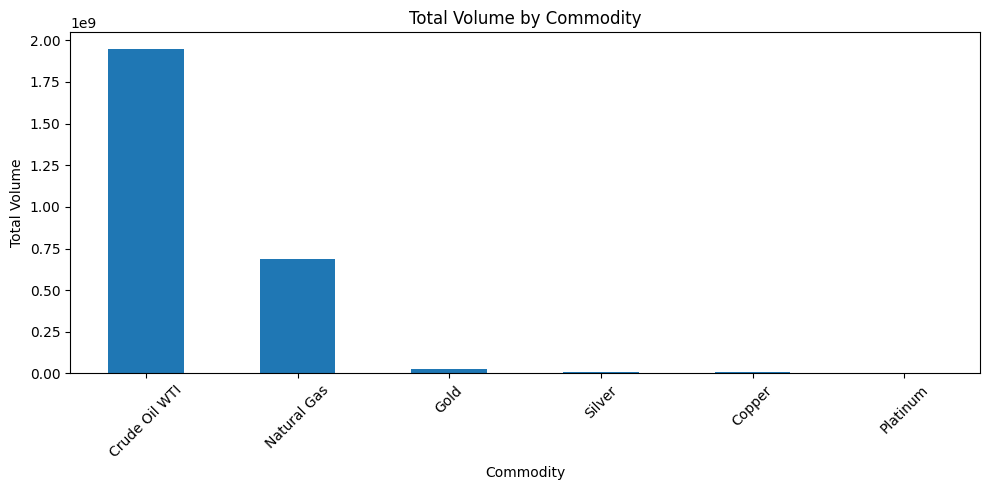

In [24]:
import matplotlib.pyplot as plt

# Group and sum volume
volume_data = df.groupby('Commodity')['Volume'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
volume_data.plot(kind='bar')

plt.title("Total Volume by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Total Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top 5 Commodities by Volume (Pie Chart)

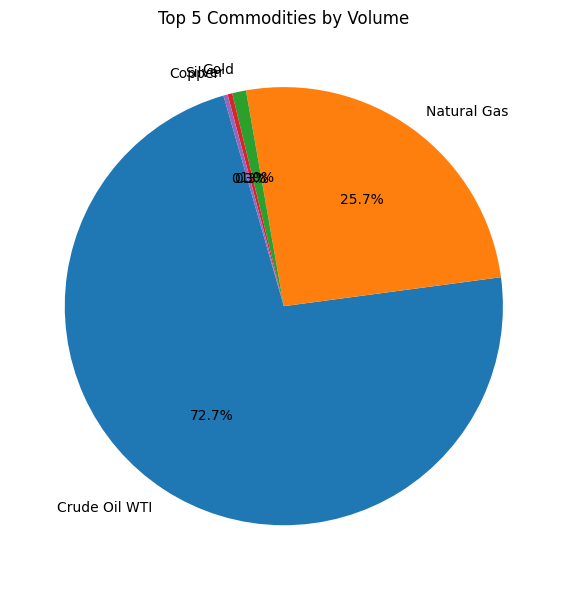

In [30]:
import matplotlib.pyplot as plt

# Aggregate total volume
volume_data = (
    df.groupby('Commodity')['Volume']
      .sum()
      .sort_values(ascending=False)
)

# Take top 5 (VERY IMPORTANT to avoid clutter)
top_data = volume_data.head(5)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    top_data,
    labels=top_data.index,
    autopct='%1.1f%%',   # show percentage
    startangle=106       # rotate for better spacing
)

plt.title("Top 5 Commodities by Volume")
plt.tight_layout()
plt.show()

### Volume Distribution for Silver, Gold, and Copper(extract 1.6% of materials into 100% for better understanding

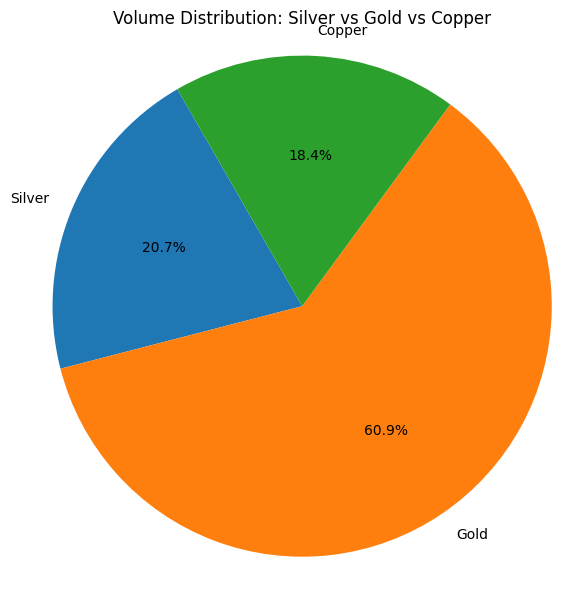

In [33]:
import matplotlib.pyplot as plt

# Select specific commodities safely
selected = ['Silver', 'Gold', 'Copper']
filtered_data = volume_data.reindex(selected).dropna()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    filtered_data,
    labels=filtered_data.index,
    autopct='%1.1f%%',
    startangle=120
)

plt.title("Volume Distribution: Silver vs Gold vs Copper")
plt.axis('equal')  # Keep circle shape
plt.tight_layout()
plt.show()

### Price Trends for Gold, Silver, and Copper

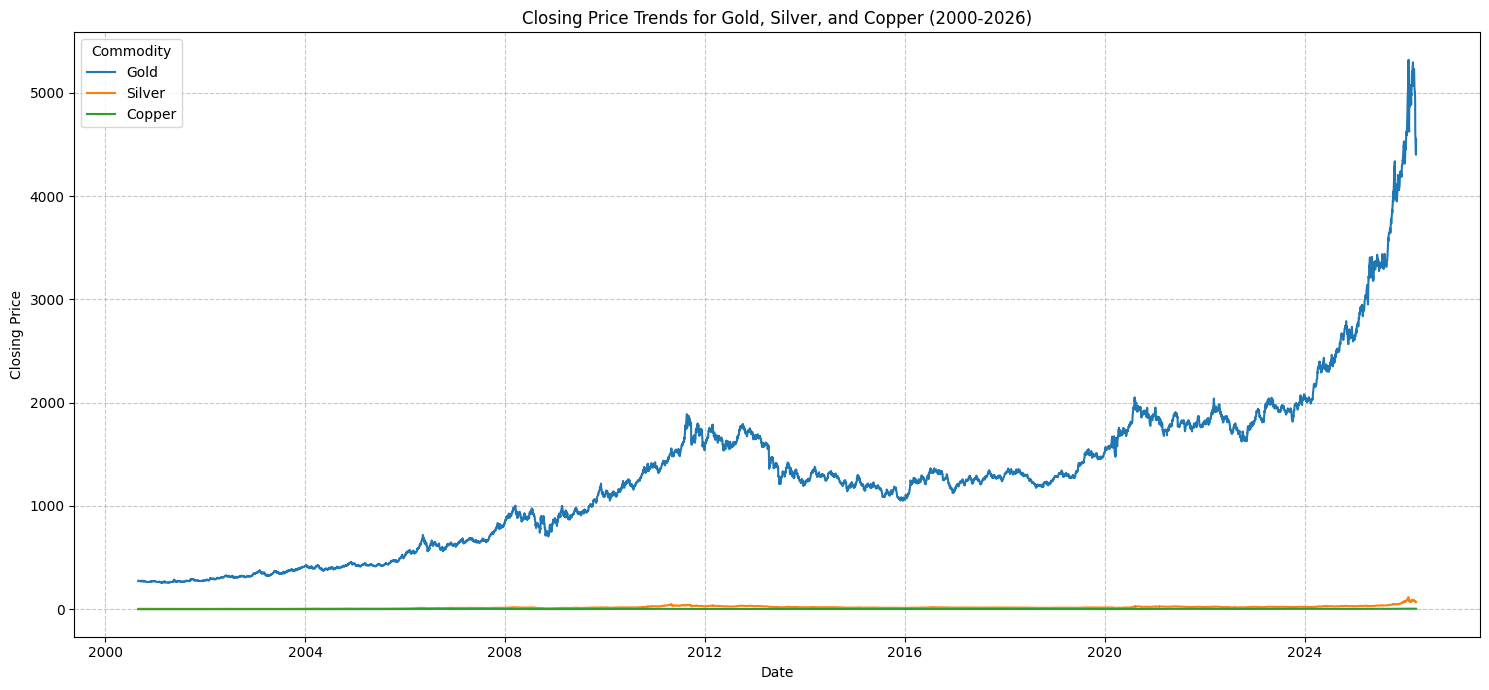

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for Gold, Silver, and Copper
selected_commodities = ['Gold', 'Silver', 'Copper']
filtered_df = df[df['Commodity'].isin(selected_commodities)].copy()

# Ensure 'Date' is datetime and sort by Date
filtered_df['Date'] = pd.to_datetime(filtered_df['Date'])
filtered_df = filtered_df.sort_values(by='Date')

# Plotting the Close price trend
plt.figure(figsize=(15, 7))
sns.lineplot(data=filtered_df, x='Date', y='Close', hue='Commodity')

plt.title('Closing Price Trends for Gold, Silver, and Copper (2000-2026)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Commodity')
plt.tight_layout()
plt.show()

### Trend Chart of Daily Price Difference (Close - Open) for All Commodities

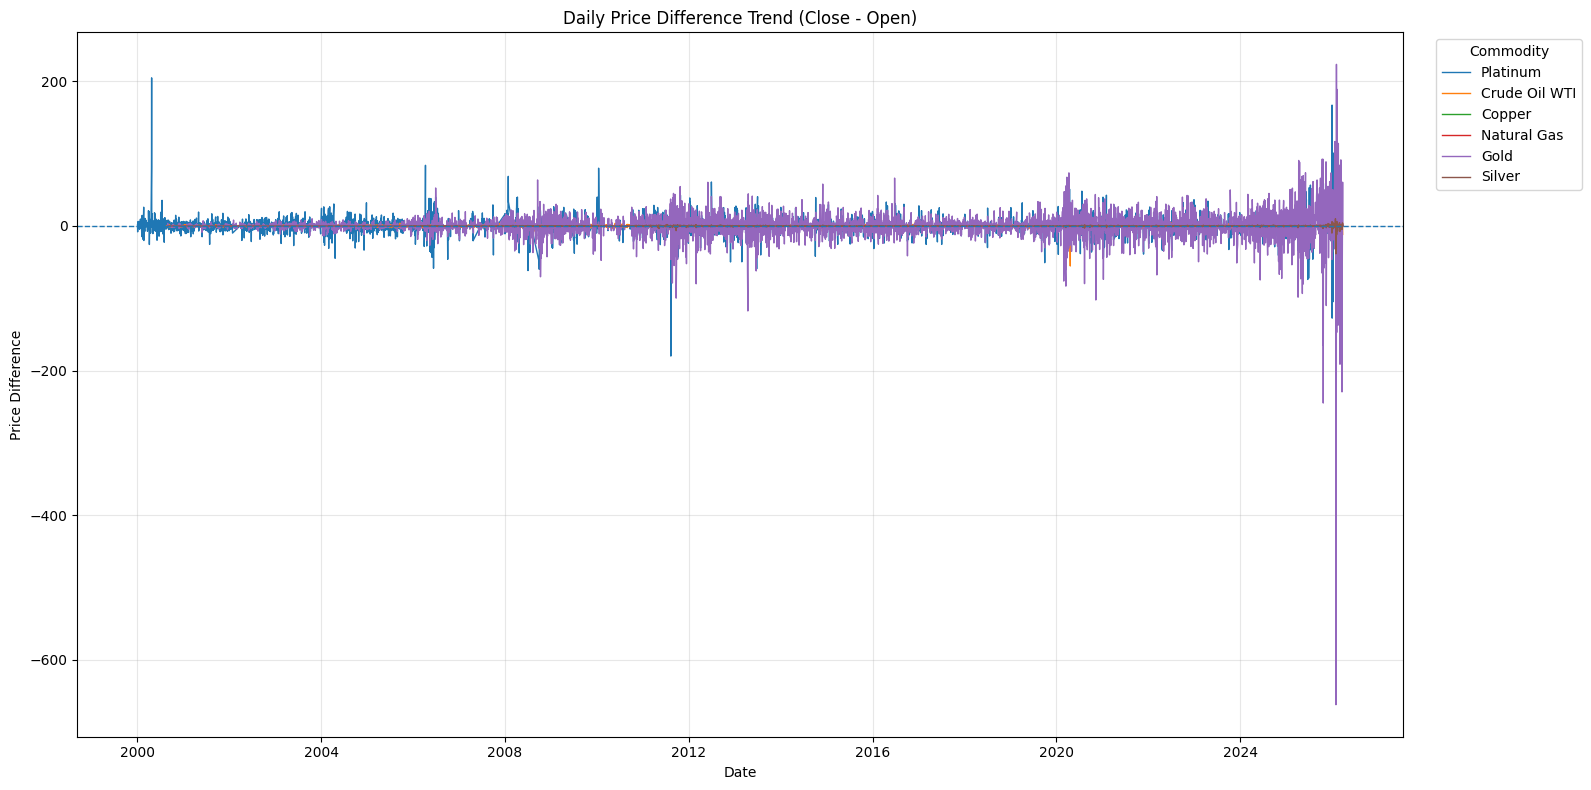

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

sns.lineplot(
    data= df_all_commodities_trends,
    x='Date',
    y='Daily_Price_Difference',
    hue='Commodity',
    linewidth=1
)

plt.title("Daily Price Difference Trend (Close - Open)")
plt.xlabel("Date")
plt.ylabel("Price Difference")

# Reference line (very important)
plt.axhline(0, linestyle='--', linewidth=1)

# Grid (lighter for clarity)
plt.grid(alpha=0.3)

# Move legend outside
plt.legend(title='Commodity', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()